# Introduction 

YouTube comment sections are often targeted by spam messages containing promotional links, misleading content, or repeated phrases. Manual moderation is inefficient due to the volume and diversity of comments.

This project investigates the effectiveness of machine learning techniques for detecting spam comments using the YouTube Spam Collection dataset from the UCI Machine Learning Repository. Both unsupervised learning and supervised learning approaches are applied to explore patterns in comment text and to build predictive spam classifiers.

# Objectives
- To explore patterns in YouTube comments using unsupervised learning
- To build supervised models for spam classification
- To compare model performance across different YouTube datasets
- To evaluate models using appropriate classification metrics


# Dataset

The YouTube Spam Collection consists of five datasets, each representing comments from different YouTube channels. Each comment is labeled as spam (1) or non-spam/ ham (0).

### Dataset information
| Dataset | YouTube ID | # Spam | # Ham | Total | 
|-----------|---------------|-------|------|------| 
| Psy | 9bZkp7q19f0 | 175 | 175 | 350 |  
| KatyPerry | CevxZvSJLk8 | 175 | 175 | 350 |  
| LMFAO | KQ6zr6kCPj8 | 236 | 202 | 438 |  
| Eminem | uelHwf8o7_U | 245 | 203 | 448 |  
| Shakira |pRpeEdMmmQ0 | 174 | 196 | 370 |  

### Structure
1. Introduction
2. Dataset Description
3. Data Preprocessing
4. Unsupervised Learning Analysis
5. Supervised Learning Models
6. Cross-Dataset Comparison
7. Error Analysis
8. Discussion & Limitations
9. Conclusion

In [79]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from wordcloud import WordCloud
from pathlib import Path
import re
import string
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from scipy.sparse import hstack
import warnings
warnings.filterwarnings('ignore')

print("Libraries are loaded")

Libraries are loaded


In [26]:
data_dir = Path("data\\raw")

datasets = {}
file_mappings = {
    'Psy': 'Youtube01-Psy.csv',
    'KatyPerry': 'Youtube02-KatyPerry.csv', 
    'LMFAO': 'Youtube03-LMFAO.csv',
    'Eminem': 'Youtube04-Eminem.csv',
    'Shakira': 'Youtube05-Shakira.csv'
}

print("Loading datasets...\n")
for celeb, filename in file_mappings.items():
    file_path = data_dir / filename
    datasets[celeb] = pd.read_csv(file_path)
    print(f"Dataset: {celeb}")
    print("Shape:", datasets[celeb].shape)
    print("Class distribution:")
    print(datasets[celeb]['CLASS'].value_counts(normalize=True))
    print("Average comment length:", datasets[celeb]['CONTENT'].apply(len).mean())
    print(f"Missing value;\n{datasets[celeb].isnull().sum()}")
    print("-"*40)
    print()

Loading datasets...

Dataset: Psy
Shape: (350, 5)
Class distribution:
CLASS
1    0.5
0    0.5
Name: proportion, dtype: float64
Average comment length: 86.88571428571429
Missing value;
COMMENT_ID    0
AUTHOR        0
DATE          0
CONTENT       0
CLASS         0
dtype: int64
----------------------------------------

Dataset: KatyPerry
Shape: (350, 5)
Class distribution:
CLASS
1    0.5
0    0.5
Name: proportion, dtype: float64
Average comment length: 107.36857142857143
Missing value;
COMMENT_ID    0
AUTHOR        0
DATE          0
CONTENT       0
CLASS         0
dtype: int64
----------------------------------------

Dataset: LMFAO
Shape: (438, 5)
Class distribution:
CLASS
1    0.538813
0    0.461187
Name: proportion, dtype: float64
Average comment length: 60.81050228310502
Missing value;
COMMENT_ID    0
AUTHOR        0
DATE          0
CONTENT       0
CLASS         0
dtype: int64
----------------------------------------

Dataset: Eminem
Shape: (448, 5)
Class distribution:
CLASS
1    0.5

In [33]:
available_artists = list(datasets.keys())
print(f"Available datasets: {available_artists}")

# Change this list if you only want to analyze specific artists
# For now, we select ALL to ensure the most robust analysis
selected_artists = ['Psy', 'KatyPerry', 'LMFAO', 'Eminem', 'Shakira']

# Filter our dictionary to keep only the selected ones
datasets_selected = {name: datasets[name] for name in selected_artists}

print(f"Proceeding with {len(datasets_selected)} datasets.")

Available datasets: ['Psy', 'KatyPerry', 'LMFAO', 'Eminem', 'Shakira']
Proceeding with 5 datasets.


In [57]:
# Combine selected datasets into a single 'Master' DataFrame for EDA
# We add a 'SOURCE' column so we know which artist the comment came from
df_all = pd.concat(
    [df.assign(SOURCE=name) for name, df in datasets_selected.items()], 
    ignore_index=True
)

# Clean up: We only need the text, the class, and the source artist
df_all = df_all[['CONTENT', 'CLASS', 'SOURCE']]
df_all.rename(columns={'SOURCE':'ARTIST'}, inplace=True)

print("Master DataFrame for EDA created:")
df_all.info()

Master DataFrame for EDA created:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1956 entries, 0 to 1955
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   CONTENT  1956 non-null   object
 1   CLASS    1956 non-null   int64 
 2   ARTIST   1956 non-null   object
dtypes: int64(1), object(2)
memory usage: 46.0+ KB


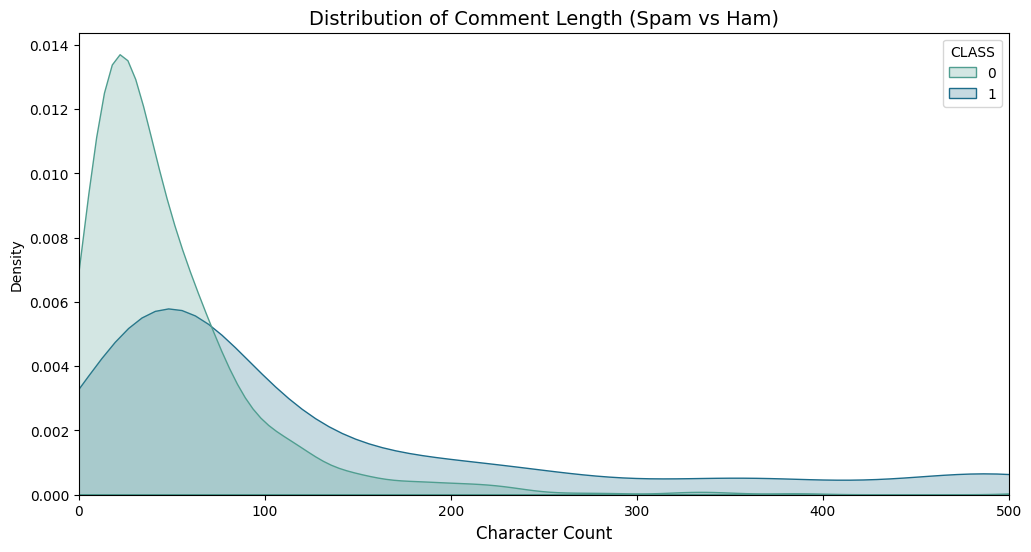

Average comment length:
        count        mean         std   min   25%   50%    75%     max
CLASS                                                                 
0       951.0   49.644585   56.284782   2.0  18.0  34.0   62.0   753.0
1      1005.0  137.336318  158.977404  10.0  36.0  65.0  171.0  1200.0


In [59]:
# Calculate length of each comment
df_all['length'] = df_all['CONTENT'].str.len()

plt.figure(figsize=(12, 6))
# Using KDE plot to see the density distribution of lengths
sns.kdeplot(data=df_all, x='length', hue='CLASS', fill=True, common_norm=False, palette='crest')

plt.title('Distribution of Comment Length (Spam vs Ham)', fontsize=14)
plt.xlabel('Character Count', fontsize=12)
plt.xlim(0, 500) # Most comments are under 500 characters
plt.show()

# Quick statistical check
print("Average comment length:")
print(df_all.groupby('CLASS')['length'].describe())

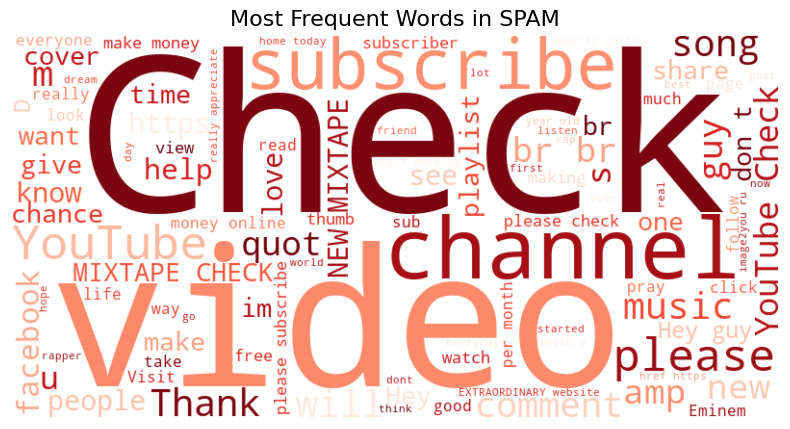

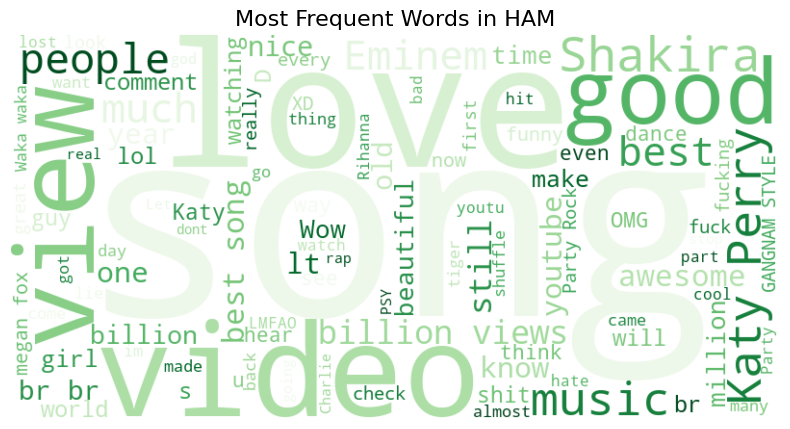

In [60]:
# Split the data into two strings
spam_words = ' '.join(df_all[df_all['CLASS'] == 1]['CONTENT'])
ham_words = ' '.join(df_all[df_all['CLASS'] == 0]['CONTENT'])

# Function to generate word clouds
def create_cloud(text, title, color):
    wc = WordCloud(width=800, height=400, background_color='white', colormap=color, max_words=100).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

create_cloud(spam_words, "Most Frequent Words in SPAM", "Reds")
create_cloud(ham_words, "Most Frequent Words in HAM", "Greens")

In [61]:
# 1. Comment Length (Characters)
df_all['char_count'] = df_all['CONTENT'].str.len()

# 2. Word Count
df_all['word_count'] = df_all['CONTENT'].apply(lambda x: len(str(x).split()))

# 3. Presence of URLs (Very common in YouTube Spam)
df_all['has_url'] = df_all['CONTENT'].str.contains('http|https|www|.com', flags=re.IGNORECASE).astype(int)

# 4. Uppercase Ratio (SHOUTING detection)
df_all['cap_ratio'] = df_all['CONTENT'].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / len(str(x)) if len(str(x)) > 0 else 0)

# View average features per class
df_all.groupby('CLASS')[['char_count', 'word_count', 'has_url', 'cap_ratio']].mean()

,char_count,word_count,has_url,cap_ratio
CLASS,,,,
0,49.644585,9.100946,0.057834,0.091474
1,137.336318,21.714428,0.358209,0.109295


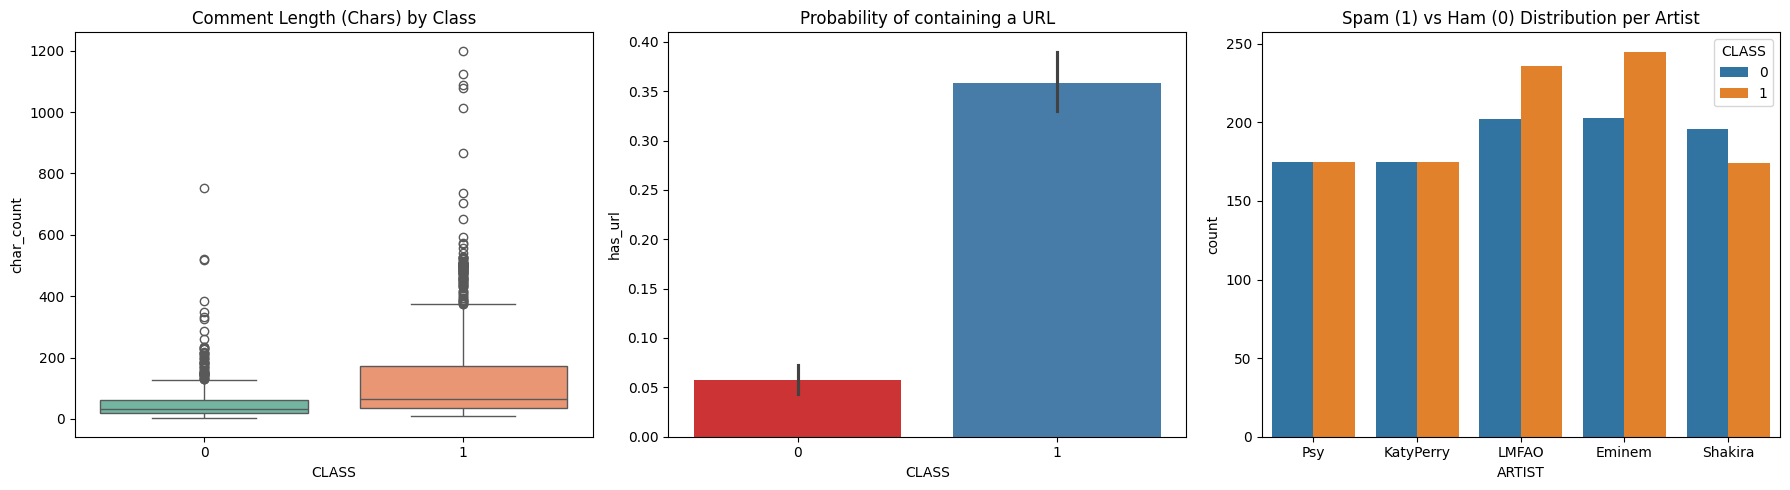

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Character Count Distribution
sns.boxplot(ax=axes[0], data=df_all, x='CLASS', y='char_count', palette='Set2')
axes[0].set_title('Comment Length (Chars) by Class')
# axes[0].set_ylim(0, 400) # Zoom in on the bulk of comments

# Plot 2: URL Presence
sns.barplot(ax=axes[1], data=df_all, x='CLASS', y='has_url', palette='Set1')
axes[1].set_title('Probability of containing a URL')

# Plot 3: Distribution across Artists
sns.countplot(ax=axes[2], data=df_all, x='ARTIST', hue='CLASS')
axes[2].set_title('Spam (1) vs Ham (0) Distribution per Artist')

plt.tight_layout()
plt.show()

In [73]:
# Load standard English stop words
stop_words = text.ENGLISH_STOP_WORDS

def master_clean(raw_text):
    # 1. Lowercase and remove HTML/URLs
    raw_text = str(raw_text).lower()
    raw_text = re.sub(r'<.*?>', '', raw_text)
    raw_text = re.sub(r'http\S+|www\S+|https\S+', '', raw_text)
    
    # 2. Remove punctuation and numbers
    raw_text = raw_text.translate(str.maketrans('', '', string.punctuation))
    raw_text = re.sub(r'\d+', '', raw_text)
    
    # 3. Remove Stop Words and extra spaces
    words = raw_text.split()
    clean_words = [w for w in words if w not in stop_words]
    
    return " ".join(clean_words)

# Apply to the dataframe
df_all['CLEAN_CONTENT'] = df_all['CONTENT'].apply(master_clean)

# Drop rows that became empty (e.g., a comment that was just a link)
df_all = df_all[df_all['CLEAN_CONTENT'].str.strip() != ''].reset_index(drop=True)

print("Text cleaning complete. New column 'CLEAN_CONTENT' created.")

Text cleaning complete. New column 'CLEAN_CONTENT' created.


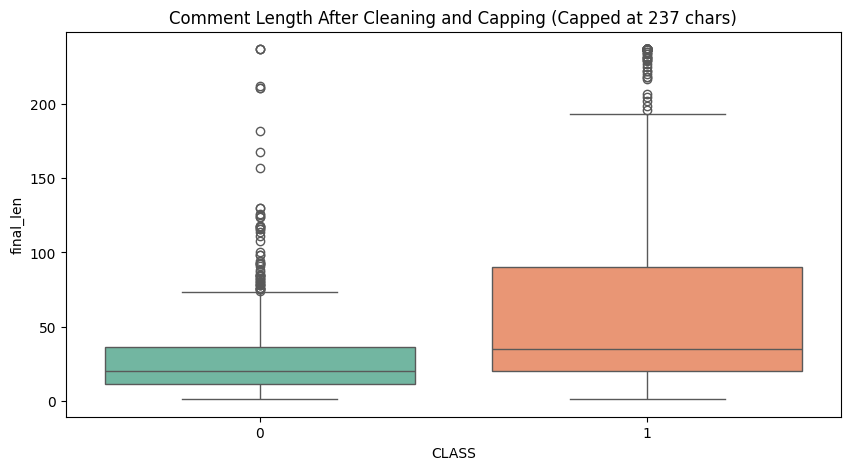

In [75]:
# 1. Calculate the 'Clean' length
df_all['clean_len'] = df_all['CLEAN_CONTENT'].str.len()

# 2. Find the 95th percentile (The 'Cap' limit)
cap_limit = df_all['clean_len'].quantile(0.95)

# 3. Create a final column where everything above the limit is capped
df_all['final_len'] = df_all['clean_len'].clip(upper=cap_limit)

# 4. Check the boxplot again - it should look much tighter now
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_all, x='CLASS', y='final_len', palette='Set2')
plt.title(f'Comment Length After Cleaning and Capping (Capped at {int(cap_limit)} chars)')
plt.show()

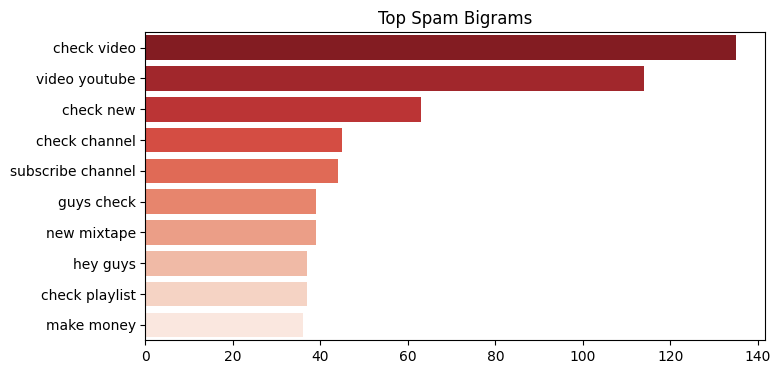

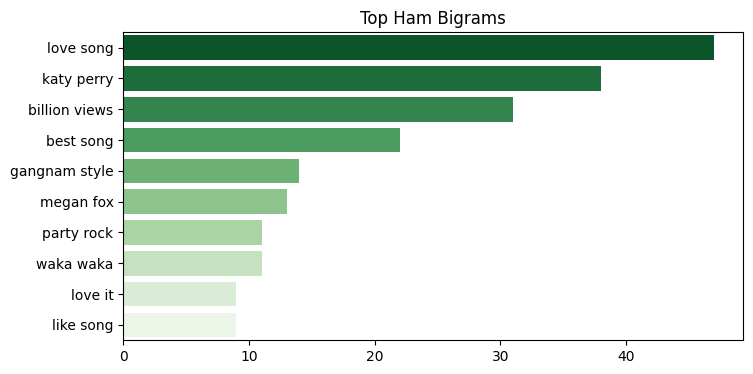

In [74]:
def plot_top_ngrams(corpus, title, color):
    # We use (2, 2) to find 2-word phrases (Bigrams)
    vec = CountVectorizer(ngram_range=(2, 2)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)[:10]
    
    # Plotting
    words, counts = zip(*words_freq)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=list(counts), y=list(words), palette=color)
    plt.title(title)
    plt.show()

# Visualize for Spam
plot_top_ngrams(df_all[df_all['CLASS'] == 1]['CLEAN_CONTENT'], "Top Spam Bigrams", "Reds_r")

# Visualize for Ham
plot_top_ngrams(df_all[df_all['CLASS'] == 0]['CLEAN_CONTENT'], "Top Ham Bigrams", "Greens_r")

In [77]:
# 1. Initialize TF-IDF Vectorizer
# We limit to 1000 words to keep the model fast and focused
tfidf = TfidfVectorizer(max_features=1000)

# 2. Transform the CLEAN_CONTENT into a numerical matrix
X_text = tfidf.fit_transform(df_all['CLEAN_CONTENT'])

# 3. Add our 'numerical' feature (the capped length) back into the mix
# We convert final_len to a 2D array so it can be merged
X_length = df_all[['final_len']].values

# 4. Combine text features and length features into one Master Feature Set (X)
X_combined = hstack([X_text, X_length])

print(f"Success! Your text has been converted into a matrix of shape: {X_combined.shape}")

Success! Your text has been converted into a matrix of shape: (1915, 1001)


--- Cluster vs Actual Class ---
cluster    0    1
CLASS            
0        926   23
1        760  206


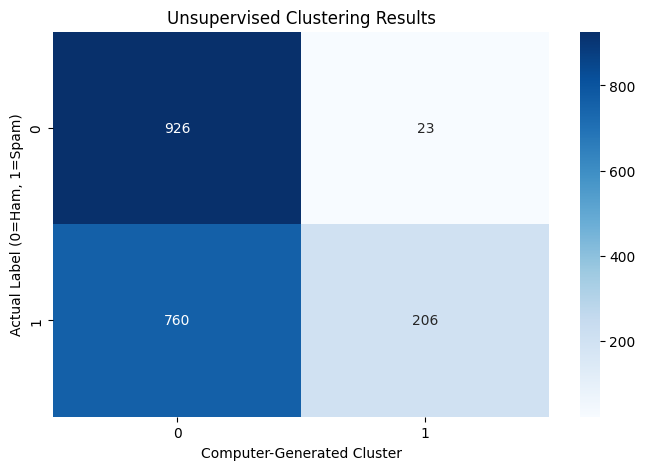

In [78]:
from sklearn.cluster import KMeans

# 1. Ask K-Means to find 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_all['cluster'] = kmeans.fit_predict(X_combined)

# 2. Check the results: Does Cluster 0 match Class 0?
comparison = pd.crosstab(df_all['CLASS'], df_all['cluster'])
print("--- Cluster vs Actual Class ---")
print(comparison)

# 3. Visualize the 'Success' of the unsupervised learning
plt.figure(figsize=(8, 5))
sns.heatmap(comparison, annot=True, fmt='d', cmap='Blues')
plt.title('Unsupervised Clustering Results')
plt.xlabel('Computer-Generated Cluster')
plt.ylabel('Actual Label (0=Ham, 1=Spam)')
plt.show()

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

# 1. Split the data into Training (80%) and Testing (20%)
# We use the X_combined we created earlier (Text + Length)
X = X_combined
y = df_all['CLASS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train a Supervised Model (Naive Bayes)
model = MultinomialNB()
model.fit(X_train, y_train)

# 3. Predict on the Test set
y_pred = model.predict(X_test)

# 4. Check the results
print("--- Supervised Learning Performance ---")
print(classification_report(y_test, y_pred))

--- Supervised Learning Performance ---
              precision    recall  f1-score   support

           0       0.95      0.72      0.82       195
           1       0.77      0.96      0.85       188

    accuracy                           0.84       383
   macro avg       0.86      0.84      0.84       383
weighted avg       0.86      0.84      0.84       383



In [81]:
from sklearn.preprocessing import MinMaxScaler

# Scale the length so it is also between 0 and 1
scaler = MinMaxScaler()
X_length_scaled = scaler.fit_transform(df_all[['final_len']])

# Re-combine and Re-train
X_combined_v2 = hstack([X_text, X_length_scaled])

# Repeat the train_test_split and model training with X_combined_v2